# Aula 09 - KNN: Técnicas de Classificação

Este notebook acompanha a versão final dos slides `aula_09_knn_classificacao.tex/pdf`.

Ele tem três objetivos:

1. gerar as figuras usadas nos slides;
2. reproduzir os resultados numéricos apresentados;
3. servir como roteiro comentado para estudo

Referência principal do plano de ensino: Joel Grus, *Data Science do Zero: Noções Fundamentais com Python*, 2ª ed., Alta Books, 2020.

## 1. Configuração do ambiente

Nesta primeira célula importamos as bibliotecas usadas ao longo da aula.  

Todo o fluxo de aprendizado de máquina será feito com `scikit-learn`, usando:

- `train_test_split` para separar treino e teste;
- `StandardScaler` para padronizar entradas;
- `Pipeline` para encadear pré-processamento e modelo;
- `KNeighborsClassifier` para implementar o KNN;
- métricas e gráficos de avaliação.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funções e classes do scikit-learn usadas na aula.
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Semente fixa para que os resultados sejam reprodutíveis.
RANDOM_STATE = 42

# Pasta onde as figuras do notebook são salvas.
# O arquivo .tex final usa essas imagens por meio de \includegraphics.
FIG_DIR = Path("figuras_knn")
FIG_DIR.mkdir(exist_ok=True)

# Ajustes visuais padronizados para as figuras.
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Métricas de distância

O KNN depende diretamente de uma noção de distância.  
Nos slides, a distância de Minkowski aparece como:

$$
d_p(x,z)=\left(\sum_{\ell=1}^{m}|x_\ell-z_\ell|^p\right)^{1/p}.
$$

A figura abaixo compara três geometrias comuns:

- Manhattan: `p=1`;
- Euclidiana: `p=2`;
- Chebyshev: limite quando `p` tende ao infinito.

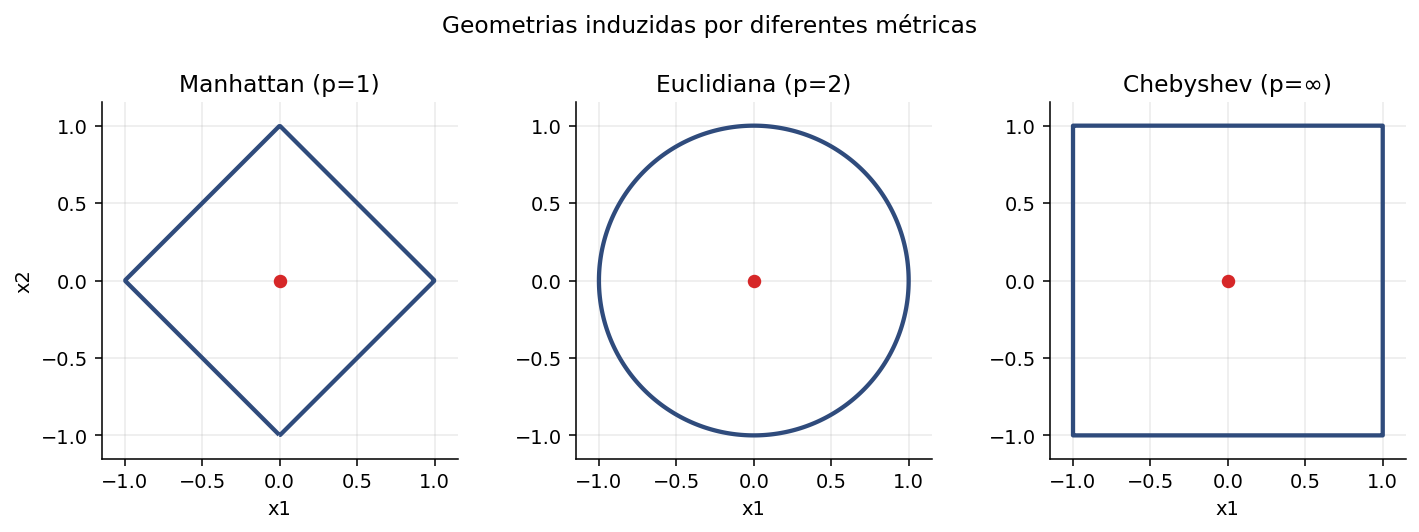

In [2]:
# Criamos uma malha 2D centrada na origem.
# Cada ponto da malha representa uma possível diferença entre dois vetores.
grid = np.linspace(-1.2, 1.2, 360)
xx, yy = np.meshgrid(grid, grid)

# Calculamos três distâncias em relação à origem.
# A curva de nível d=1 mostra a 'bola unitária' de cada métrica.
dist_l1 = np.abs(xx) + np.abs(yy)                 # Manhattan
dist_l2 = np.sqrt(xx**2 + yy**2)                  # Euclidiana
dist_linf = np.maximum(np.abs(xx), np.abs(yy))    # Chebyshev

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))

for ax, dist, title in zip(
    axes,
    [dist_l1, dist_l2, dist_linf],
    ["Manhattan (p=1)", "Euclidiana (p=2)", "Chebyshev (p=∞)"],
):
    # Desenha apenas a curva onde a distância até a origem vale 1.
    ax.contour(xx, yy, dist, levels=[1.0], colors=["#2f4b7c"], linewidths=2.2)
    ax.scatter([0], [0], color="#d62728", s=35, zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_title(title)
    ax.set_xlabel("x1")

axes[0].set_ylabel("x2")
fig.suptitle("Geometrias induzidas por diferentes métricas", y=1.03)
fig.tight_layout()

# Figura usada nos slides.
fig.savefig(FIG_DIR / "knn_metricas_distancia.png", bbox_inches="tight")
plt.show()

## 3. Votação uniforme e ponderada

Os slides separam duas ideias:

1. **votação uniforme:** cada vizinho conta como um voto;
2. **votação ponderada pela distância:** vizinhos mais próximos têm maior peso.

A célula abaixo usa um exemplo numérico pequeno para deixar a regra de decisão transparente.

In [3]:
# Exemplo didático: cinco vizinhos mais próximos de uma nova amostra.
# Cada vizinho tem uma classe e uma distância até o novo ponto.
neighbors = pd.DataFrame({
    "vizinho": [1, 2, 3, 4, 5],
    "classe": ["vermelho", "azul", "vermelho", "vermelho", "azul"],
    "distancia": [0.35, 0.42, 0.60, 0.75, 0.95],
})

# Votação uniforme:
# contamos quantas vezes cada classe aparece entre os k vizinhos.
uniform_votes = neighbors["classe"].value_counts()

# Votação ponderada:
# usamos peso = 1 / (distância + epsilon).
# epsilon evita divisão por zero se a distância for exatamente nula.
epsilon = 1e-9
neighbors["peso"] = 1.0 / (neighbors["distancia"] + epsilon)
weighted_votes = neighbors.groupby("classe")["peso"].sum().sort_values(ascending=False)

print("Vizinhos considerados:")
display(neighbors)

print("\nVotação uniforme:")
display(uniform_votes)

print("\nVotação ponderada pela distância:")
display(weighted_votes)

Vizinhos considerados:


,vizinho,classe,distancia,peso
0,1,vermelho,0.35,2.857143
1,2,azul,0.42,2.380952
2,3,vermelho,0.60,1.666667
3,4,vermelho,0.75,1.333333
4,5,azul,0.95,1.052632



Votação uniforme:


classe
vermelho    3
azul        2
Name: count, dtype: int64


Votação ponderada pela distância:


classe
vermelho    5.857143
azul        3.433584
Name: peso, dtype: float64

## 4. Dados sintéticos: sensores de motor elétrico

Esta seção gera a base sintética usada no primeiro exemplo dos slides.

A interpretação didática é:

- cada linha é uma janela de medição de um motor elétrico;
- `x1` representa corrente RMS estimada;
- `x2` representa THD estimada;
- o alvo representa uma condição operacional: normal, desalinhamento ou falha elétrica.

In [6]:
# make_classification cria uma base controlada para demonstração.
# Usamos duas variáveis porque isso permite desenhar os pontos e as fronteiras.
X_raw, y = make_classification(
    n_samples=360,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.35,
    flip_y=0.04,          # pequeno ruído nos rótulos para deixar o problema realista
    random_state=RANDOM_STATE,
)

# Reescalamos as duas variáveis para unidades didáticas com contexto em Engenharia.
# A ideia é representar corrente RMS em ampères e THD em porcentagem.
current_rms = 8 + 2.1 * X_raw[:, 0]
thd = 5 + 2.4 * X_raw[:, 1]

# Nos slides, a matriz de atributos é chamada simplesmente de X.
X = np.column_stack([current_rms, thd])

# Nomes legíveis para as classes.
class_names = np.array(["Normal", "Desalinhamento", "Falha elétrica"])

# Tabela auxiliar apenas para visualização.
df_motor = pd.DataFrame(X, columns=["corrente_rms_A", "thd_percentual"])
df_motor["classe"] = class_names[y]

df_motor.head()

,corrente_rms_A,thd_percentual,classe
0,11.454795,1.114749,Normal
1,11.034021,1.200571,Normal
2,9.226310,3.760848,Normal
3,12.330529,14.201700,Desalinhamento
4,5.735804,-1.358497,Falha elétrica


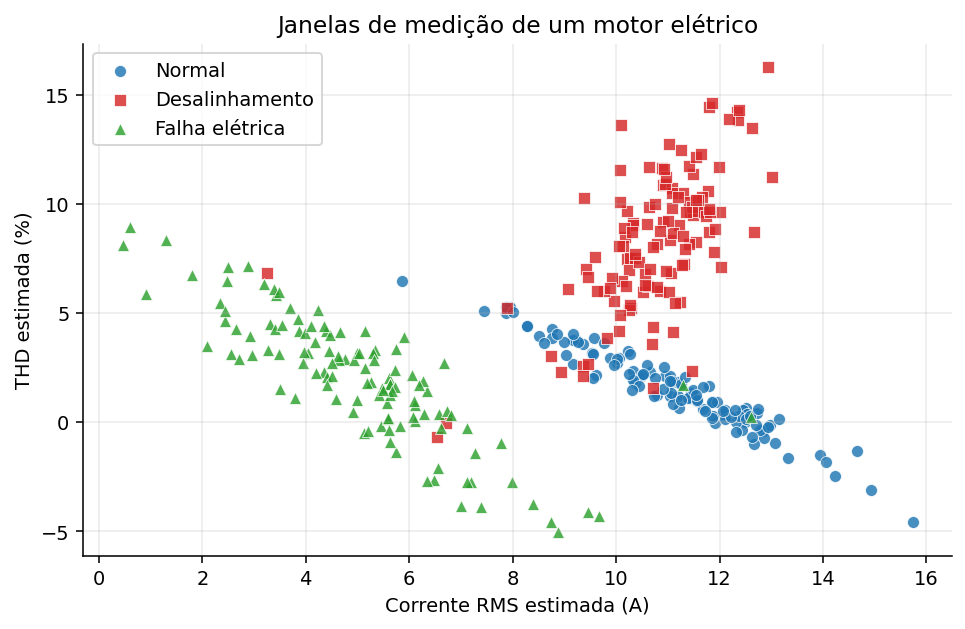

In [7]:
# Figura de dispersão usada nos slides: knn_dados_motores.png.
colors = ["#1f77b4", "#d62728", "#2ca02c"]
markers = ["o", "s", "^"]

fig, ax = plt.subplots(figsize=(7.0, 4.6))

for cls, color, marker in zip(range(3), colors, markers):
    mask = y == cls
    ax.scatter(
        X[mask, 0],
        X[mask, 1],
        s=38,
        alpha=0.82,
        color=color,
        marker=marker,
        edgecolor="white",
        linewidth=0.45,
        label=class_names[cls],
    )

ax.set_xlabel("Corrente RMS estimada (A)")
ax.set_ylabel("THD estimada (%)")
ax.set_title("Janelas de medição de um motor elétrico")
ax.legend(frameon=True)
fig.tight_layout()

# Figura incluída no slide 'Dados sintéticos: sensores de motor'.
fig.savefig(FIG_DIR / "knn_dados_motores.png", bbox_inches="tight")
plt.show()

## 5. Separação em treino e teste

Esta célula corresponde ao slide **Separação dos dados em treino e teste**.

O uso de `stratify=y` é importante porque mantém proporções semelhantes das três classes nos conjuntos de treino e teste.

In [10]:
# Dividimos os dados antes de treinar o modelo.
# O teste é reservado para avaliar o modelo em amostras não vistas.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste:  {X_test.shape[0]}")
print("Distribuição das classes no treino:")
display(pd.Series(class_names[y_train]).value_counts())
print("Distribuição das classes no teste:")
display(pd.Series(class_names[y_test]).value_counts())

Amostras de treino: 252
Amostras de teste:  108
Distribuição das classes no treino:


Desalinhamento    88
Falha elétrica    83
Normal            81
Name: count, dtype: int64

Distribuição das classes no teste:


Desalinhamento    37
Falha elétrica    36
Normal            35
Name: count, dtype: int64

## 6. Pipeline com normalização e KNN

O KNN usa distâncias. Por isso, a escala dos atributos importa.

Nos slides usamos:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7, weights="distance")),
])
```

O `Pipeline` evita vazamento de informação: o `StandardScaler` aprende média e desvio padrão apenas no treino e aplica a mesma transformação no teste.

In [13]:
# Pipeline usado no slide.
# StandardScaler padroniza as variáveis: média 0 e desvio padrão 1.
# KNeighborsClassifier implementa o KNN propriamente dito.
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
    )),
])

# fit: aprende as estatísticas de escala e armazena os exemplos de treino.
knn_model.fit(X_train, y_train)

# predict: classifica as amostras de teste.
y_pred = knn_model.predict(X_test)

# Acurácia apresentada nos slides.
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia no teste: {test_accuracy:.3f}")

# Relatório por classe: precisão, recall e F1-score.
print(classification_report(y_test, y_pred, target_names=class_names))

Acurácia no teste: 0.963
                precision    recall  f1-score   support

        Normal       0.90      1.00      0.95        35
Desalinhamento       1.00      0.89      0.94        37
Falha elétrica       1.00      1.00      1.00        36

      accuracy                           0.96       108
     macro avg       0.97      0.96      0.96       108
  weighted avg       0.97      0.96      0.96       108



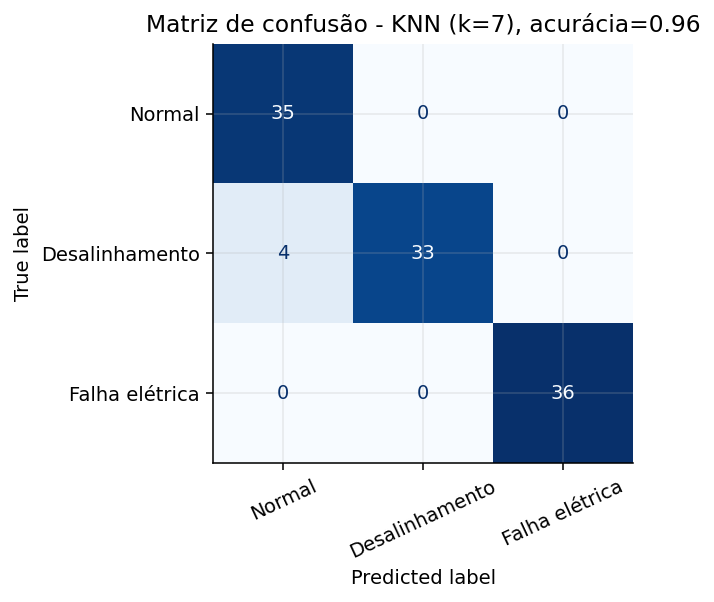

In [8]:
# Matriz de confusão usada nos slides: knn_matriz_confusao.png.
# Linhas: classes reais. Colunas: classes previstas.
fig, ax = plt.subplots(figsize=(5.3, 4.4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

ax.set_title(f"Matriz de confusão - KNN (k=7), acurácia={test_accuracy:.2f}")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / "knn_matriz_confusao.png", bbox_inches="tight")
plt.show()

## 7. Efeito do valor de k na fronteira de decisão

O slide **Como o valor de k muda a fronteira?** compara `k=1`, `k=7` e `k=31`.

Interpretação:

- `k=1`: modelo muito local, fronteira irregular, maior risco de sobreajuste;
- `k=7`: suavização intermediária;
- `k=31`: fronteira mais suave, maior risco de subajuste.

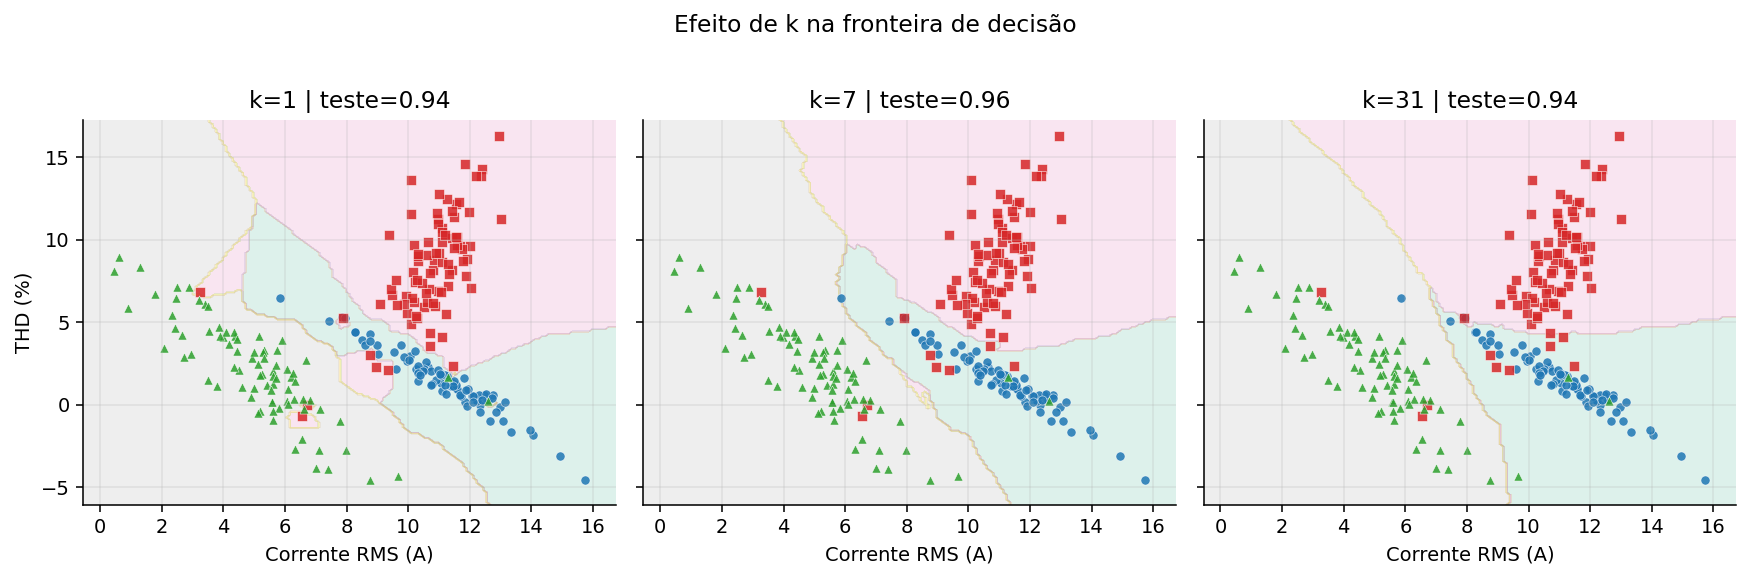

In [9]:
# Criamos três modelos KNN com diferentes valores de k.
# Para cada valor, desenhamos a região do plano classificada como cada classe.
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.0), sharex=True, sharey=True)

for ax, k in zip(axes, [1, 7, 31]):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    model.fit(X_train, y_train)

    # DecisionBoundaryDisplay avalia o modelo em uma malha de pontos.
    # O resultado mostra a fronteira de decisão induzida pelo KNN.
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        grid_resolution=160,
        alpha=0.22,
        cmap=plt.cm.Set2,
        ax=ax,
    )

    # Sobrepomos os pontos de treino para facilitar a interpretação.
    for cls, color, marker in zip(range(3), colors, markers):
        mask = y_train == cls
        ax.scatter(
            X_train[mask, 0],
            X_train[mask, 1],
            s=22,
            color=color,
            marker=marker,
            edgecolor="white",
            linewidth=0.3,
            alpha=0.85,
        )

    acc = model.score(X_test, y_test)
    ax.set_title(f"k={k} | teste={acc:.2f}")
    ax.set_xlabel("Corrente RMS (A)")

axes[0].set_ylabel("THD (%)")
fig.suptitle("Efeito de k na fronteira de decisão", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "knn_fronteiras_k.png", bbox_inches="tight")
plt.show()

## 8. Seleção de k por validação cruzada

Usamos validação cruzada estratificada com 5 partições para escolher `k`.  
O conjunto de teste fica reservado para avaliação final e não deve ser usado para escolher o hiperparâmetro.

In [31]:
# Valores candidatos para k.
# Usamos apenas valores ímpares para reduzir a chance de empate na votação.
k_values = list(range(1, 42, 2))

# StratifiedKFold mantém proporções semelhantes das classes em cada fold.
# Validação cruzada estratificada com 5 folds, embaralhamento e semente fixa para reprodutibilidade.
# Embaralhamento é misturar aleatoriamente a ordem das amostras antes de dividi-las em folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

train_scores = []
cv_means = []
cv_stds = []
test_scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])

    # Acurácia no treino: útil para observar tendência de sobreajuste.
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

    # Acurácia de validação cruzada:
    # o modelo é refeito em cada fold, sempre com o scaler dentro do pipeline.
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

# Melhor k segundo a média de validação cruzada.
best_idx = int(np.argmax(cv_means))
best_k = k_values[best_idx]
best_cv = cv_means[best_idx]

print(f"Melhor k por validação cruzada: {best_k}")
print(f"Acurácia média de validação: {best_cv:.3f}")

Melhor k por validação cruzada: 5
Acurácia média de validação: 0.956


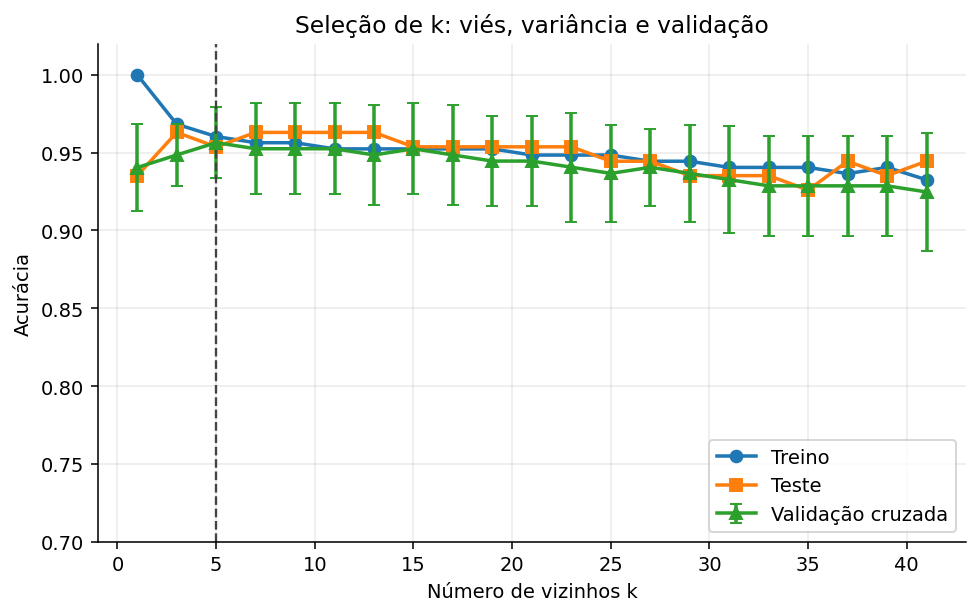

In [32]:
fig, ax = plt.subplots(figsize=(7.1, 4.5))

ax.plot(k_values, train_scores, marker="o", linewidth=1.8, label="Treino")
ax.plot(k_values, test_scores, marker="s", linewidth=1.8, label="Teste")
ax.errorbar(
    k_values,
    cv_means,
    yerr=cv_stds,
    marker="^",
    linewidth=1.8,
    capsize=3,
    label="Validação cruzada",
)

ax.axvline(best_k, color="#444444", linestyle="--", linewidth=1.2)
ax.set_xlabel("Número de vizinhos k")
ax.set_ylabel("Acurácia")
ax.set_title("Seleção de k: viés, variância e validação")
ax.set_ylim(0.70, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "knn_selecao_k.png", bbox_inches="tight")
plt.show()

## 9. Escala das variáveis

Aqui fazemos um teste numérico simples: multiplicamos a THD por 20 e comparamos o KNN com e sem padronização.

Esse trecho não gera figura para os slides finais; ele existe para apoiar a explicação do slide **KNN depende da escala**.

In [33]:
# Copiamos os dados e alteramos artificialmente a escala da segunda variável.
# Isso simula uma situação comum em engenharia: atributos medidos em unidades muito diferentes.
X_bad_scale = X.copy()
X_bad_scale[:, 1] *= 20.0

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_bad_scale,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Modelo sem normalização: as distâncias são calculadas diretamente nas escalas originais.
plain_knn = KNeighborsClassifier(n_neighbors=7)
plain_knn.fit(X_train_bad, y_train_bad)
acc_plain = plain_knn.score(X_test_bad, y_test_bad)

# Modelo com normalização: cada atributo passa a ter média 0 e desvio padrão 1.
scaled_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7)),
])
scaled_knn.fit(X_train_bad, y_train_bad)
acc_scaled = scaled_knn.score(X_test_bad, y_test_bad)

print(f"Acurácia sem normalização: {acc_plain:.3f}")
print(f"Acurácia com normalização: {acc_scaled:.3f}")

Acurácia sem normalização: 0.880
Acurácia com normalização: 0.963


## 10. Estudo de caso: estabilidade de smart grids

Esta seção corresponde ao estudo de caso dos slides.

Base usada:

> Arzamasov, V. (2018). *Electrical Grid Stability Simulated Data*. UCI Machine Learning Repository.  
> DOI: https://doi.org/10.24432/C5PG66

O alvo `stabf` indica se a rede é `stable` ou `unstable`.

In [34]:
# Lemos diretamente o arquivo .zip baixado da UCI.
# O pandas consegue abrir o CSV interno sem precisar extrair manualmente.
uci_path = Path("dados") / "electrical_grid_stability_uci.zip"
grid_df = pd.read_csv(uci_path)

print(f"Dimensão da base UCI: {grid_df.shape[0]} linhas x {grid_df.shape[1]} colunas")
print("\nDistribuição das classes:")
display(grid_df["stabf"].value_counts())

grid_df.head()

Dimensão da base UCI: 10000 linhas x 14 colunas

Distribuição das classes:


stabf
unstable    6380
stable      3620
Name: count, dtype: int64

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


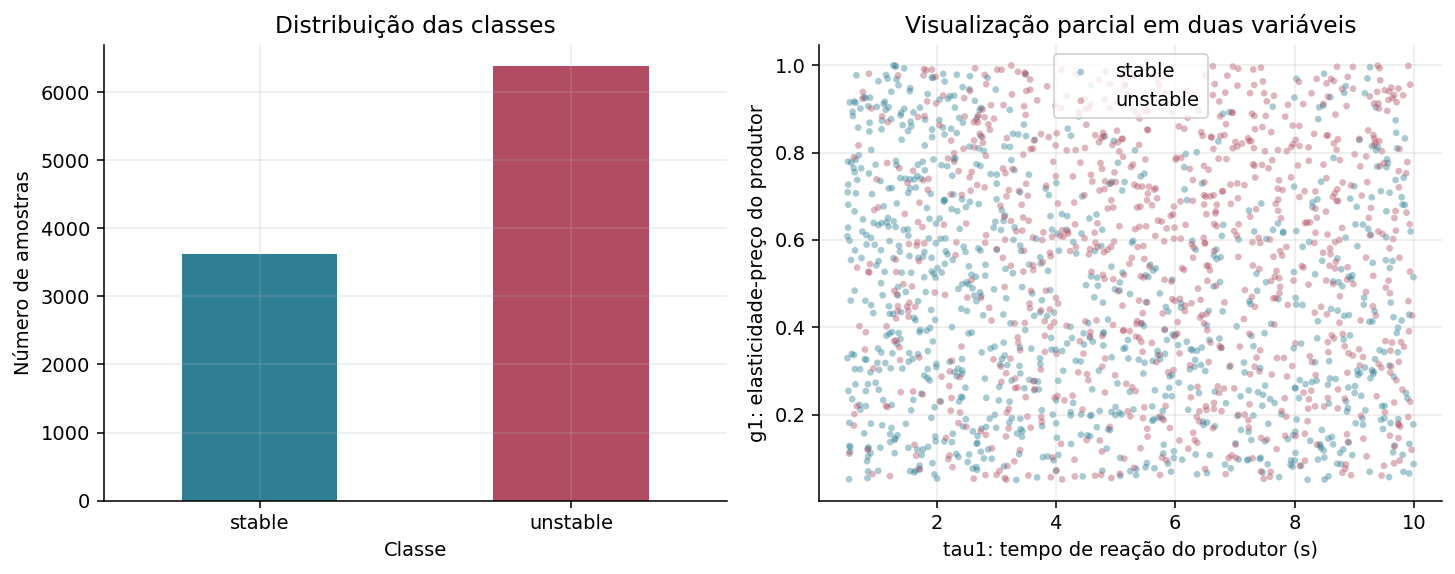

In [35]:
# Figura usada nos slides
# Ela mostra a distribuição das classes e uma projeção 2D com apenas tau1 e g1.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

grid_df["stabf"].value_counts().reindex(["stable", "unstable"]).plot(
    kind="bar",
    ax=axes[0],
    color=["#2f7f95", "#b24c63"],
    rot=0,
)
axes[0].set_title("Distribuição das classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Número de amostras")

# Amostramos pontos para não sobrecarregar a visualização.
# O modelo usa 12 variáveis; essa projeção serve apenas para inspeção visual.
for label, color in zip(["stable", "unstable"], ["#2f7f95", "#b24c63"]):
    sample = grid_df[grid_df["stabf"] == label].sample(
        900,
        random_state=RANDOM_STATE,
        replace=False,
    )
    axes[1].scatter(
        sample["tau1"],
        sample["g1"],
        s=12,
        alpha=0.42,
        color=color,
        label=label,
        edgecolor="none",
    )

axes[1].set_xlabel("tau1: tempo de reação do produtor (s)")
axes[1].set_ylabel("g1: elasticidade-preço do produtor")
axes[1].set_title("Visualização parcial em duas variáveis")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "uci_grid_distribuicao_scatter.png", bbox_inches="tight")
plt.show()

## 11. KNN na base UCI

Usamos as 12 variáveis preditivas `tau`, `p` e `g`.  
A coluna `stab` é removida porque é uma medida contínua diretamente associada à estabilidade; nos slides, a tarefa é classificar `stabf`.

Codificação do alvo:

- `0`: stable;
- `1`: unstable.

In [36]:
# Variáveis de entrada usadas pelo modelo.
feature_cols = [
    "tau1", "tau2", "tau3", "tau4",
    "p1", "p2", "p3", "p4",
    "g1", "g2", "g3", "g4",
]

X_grid = grid_df[feature_cols].to_numpy()
y_grid = (grid_df["stabf"] == "unstable").astype(int).to_numpy()
grid_class_names = np.array(["stable", "unstable"])

# Separação treino/teste com preservação da proporção das classes.
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_grid,
    y_grid,
    test_size=0.25,
    stratify=y_grid,
    random_state=RANDOM_STATE,
)

# Modelo usado nos slides:
# padronização + KNN com k=13 e pesos por distância.
grid_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=13, weights="distance")),
])

grid_knn.fit(Xg_train, yg_train)
yg_pred = grid_knn.predict(Xg_test)
grid_acc = accuracy_score(yg_test, yg_pred)

print(f"Acurácia UCI smart grid: {grid_acc:.3f}")
print(classification_report(yg_test, yg_pred, target_names=grid_class_names))

Acurácia UCI smart grid: 0.867
              precision    recall  f1-score   support

      stable       0.93      0.68      0.79       905
    unstable       0.84      0.97      0.90      1595

    accuracy                           0.87      2500
   macro avg       0.89      0.83      0.85      2500
weighted avg       0.88      0.87      0.86      2500



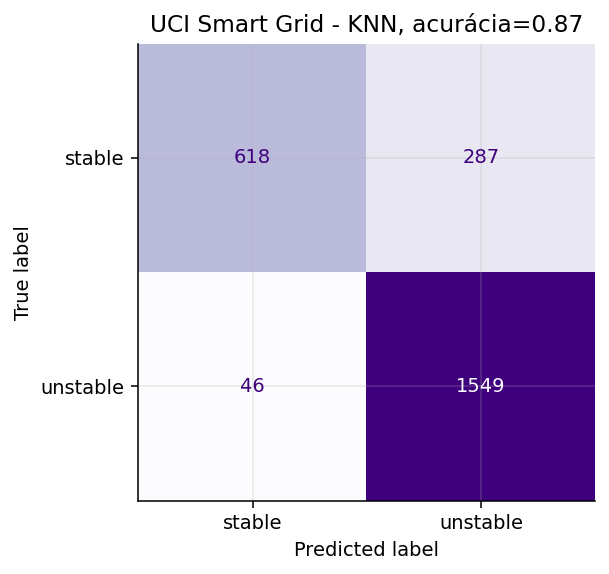

Redes instáveis no teste: 1595
Instáveis classificadas como estáveis: 46


In [38]:
# Matriz de confusão usada nos slides: uci_grid_matriz_confusao.png.
fig, ax = plt.subplots(figsize=(5.0, 4.2))

ConfusionMatrixDisplay.from_predictions(
    yg_test,
    yg_pred,
    display_labels=grid_class_names,
    cmap="Purples",
    colorbar=False,
    ax=ax,
)

ax.set_title(f"UCI Smart Grid - KNN, acurácia={grid_acc:.2f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "uci_grid_matriz_confusao.png", bbox_inches="tight")
plt.show()

# Erro crítico discutido nos slides:
# rede real instável (1) classificada como estável (0).
critical_errors = int(((yg_test == 1) & (yg_pred == 0)).sum())
unstable_total = int((yg_test == 1).sum())

print(f"Redes instáveis no teste: {unstable_total}")
print(f"Instáveis classificadas como estáveis: {critical_errors}")

## 12. Escolha de k na base UCI

No estudo de caso, os slides testam `k = 1, 5, 9, ..., 41`.  
Novamente usamos validação cruzada estratificada com 5 partições.

In [40]:
grid_k_values = list(range(1, 42, 4))
grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_cv_means = []
grid_test_scores = []

for k in grid_k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance")),
    ])

    # Validação cruzada apenas no conjunto de treino.
    scores = cross_val_score(model, Xg_train, yg_train, cv=grid_cv, scoring="accuracy")
    grid_cv_means.append(scores.mean())

    # A curva de teste é calculada para fins didáticos.
    # Na prática, o teste deve ser usado uma única vez no modelo escolhido.
    model.fit(Xg_train, yg_train)
    grid_test_scores.append(model.score(Xg_test, yg_test))

grid_best_idx = int(np.argmax(grid_cv_means))
grid_best_k = grid_k_values[grid_best_idx]
grid_best_cv = grid_cv_means[grid_best_idx]

print(f"Melhor k na base UCI: {grid_best_k}")
print(f"Acurácia média de validação: {grid_best_cv:.3f}")

Melhor k na base UCI: 17
Acurácia média de validação: 0.857


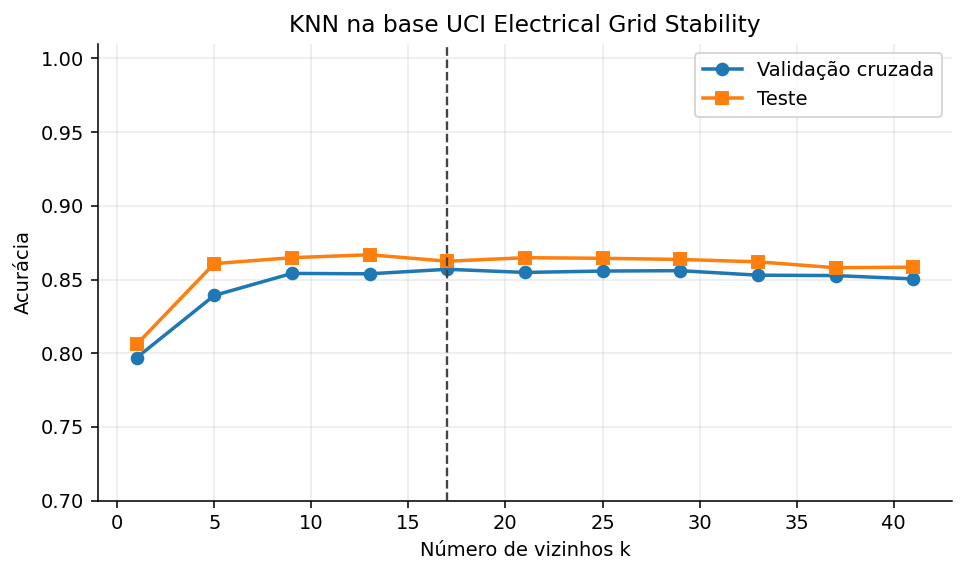

In [41]:
# Figura usada nos slides: uci_grid_selecao_k.png.
fig, ax = plt.subplots(figsize=(7.0, 4.2))

ax.plot(grid_k_values, grid_cv_means, marker="o", linewidth=1.8, label="Validação cruzada")
ax.plot(grid_k_values, grid_test_scores, marker="s", linewidth=1.8, label="Teste")
ax.axvline(grid_best_k, color="#444444", linestyle="--", linewidth=1.2)

ax.set_xlabel("Número de vizinhos k")
ax.set_ylabel("Acurácia")
ax.set_title("KNN na base UCI Electrical Grid Stability")
ax.set_ylim(0.70, 1.01)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "uci_grid_selecao_k.png", bbox_inches="tight")
plt.show()

## 13. Prática guiada

Sugestões de experimentos para acompanhar os exercícios finais dos slides:

1. Troque `weights="distance"` por `weights="uniform"` no exemplo do motor e compare a matriz de confusão.
2. Teste `metric="manhattan"` no `KNeighborsClassifier`.
3. Adicione uma terceira variável sintética, como temperatura do enrolamento, e repita a validação cruzada.
4. Na base UCI, remova `p1` e compare a acurácia.
5. Na base UCI, calcule explicitamente a taxa de redes instáveis classificadas como estáveis.